# Question 3.2 — Failure Case Analysis

**Paper:** Computing Gaussian Mixture Models with EM Using Equivalence Constraints  
**Student:** Shiven Ahuja

## Overview

This experiment investigates a failure scenario for the constrained clustering method proposed in the paper. The method assumes that equivalence constraints are correct and that all points grouped into a chunklet belong to the same underlying cluster.

To test the robustness of the method, we intentionally introduce incorrect constraints by grouping points from different true clusters into the same chunklet. This violates one of the key assumptions of the algorithm and allows us to analyze how the method behaves under noisy or incorrect constraint information.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

In [2]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=5.0,
    random_state=42
)

In [3]:
np.random.seed(42)

chunklets = []

for cluster_id in range(3):
    indices = np.where(y_true == cluster_id)[0]
    selected = np.random.choice(indices, size=10, replace=False)
    chunklets.append(selected)

X_correct = X.copy()

for chunk in chunklets:
    mean_point = np.mean(X[chunk], axis=0)
    X_correct[chunk] = mean_point

gmm_correct = GaussianMixture(n_components=3, random_state=42)
gmm_correct.fit(X_correct)

labels_correct = gmm_correct.predict(X_correct)

ari_correct = adjusted_rand_score(y_true, labels_correct)

print("ARI with correct constraints:", ari_correct)

ARI with correct constraints: 0.6993573553881396


In [4]:
# Create noisy chunklets mixing clusters

np.random.seed(42)

wrong_chunklets = []

for i in range(3):
    selected = np.random.choice(range(len(X)), size=10, replace=False)
    wrong_chunklets.append(selected)

X_wrong = X.copy()

for chunk in wrong_chunklets:
    mean_point = np.mean(X[chunk], axis=0)
    X_wrong[chunk] = mean_point

In [5]:
gmm_wrong = GaussianMixture(n_components=3, random_state=42)
gmm_wrong.fit(X_wrong)

labels_wrong = gmm_wrong.predict(X_wrong)

ari_wrong = adjusted_rand_score(y_true, labels_wrong)

print("ARI with incorrect constraints:", ari_wrong)

ARI with incorrect constraints: 0.4935006964759832


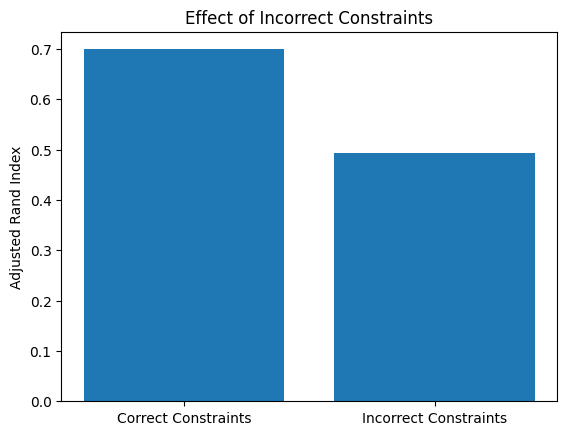

In [6]:
methods = [
    "Correct Constraints",
    "Incorrect Constraints"
]

scores = [
    ari_correct,
    ari_wrong
]

plt.bar(methods, scores)

plt.ylabel("Adjusted Rand Index")
plt.title("Effect of Incorrect Constraints")

plt.savefig("partB/results/noisy_constraints_failure.png")

plt.show()

## Interpretation

The results show that introducing incorrect equivalence constraints significantly reduces clustering performance. This behavior is expected because the constrained clustering algorithm assumes that all points within a chunklet originate from the same true cluster. When this assumption is violated, the algorithm is forced to assign points from different clusters to the same Gaussian component, which distorts the parameter estimation during the EM algorithm.

As a result, the clustering model produces incorrect cluster assignments and the Adjusted Rand Index decreases. This experiment demonstrates that the quality of equivalence constraints plays a critical role in the effectiveness of the method. If the constraint information is noisy or incorrect, the constrained clustering approach may perform worse than the unconstrained baseline.

This failure case highlights an important limitation of the method and emphasizes the importance of reliable constraint information in constrained clustering algorithms.